In [1]:
import pandas as pd

In [2]:
train=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Train_Cleaned (4).csv")

In [3]:
val=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Validation_Cleaned (3).csv")

## Data Spliting


In [4]:
# Define the features and the target and dropping irrelavant columns
X_train = train.drop(['Reservation-id', 'Reservation_Status', 'Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_train = train['Reservation_Status']

X_val = val.drop(['Reservation-id', 'Reservation_Status','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_val = val['Reservation_Status']

## Feature scaling

In [6]:
# Creating the 'Over Capacity' flag
train['Is_Over_Capacity'] = (train['Total_Guests'] > 5).astype(int)
val['Is_Over_Capacity'] = (val['Total_Guests'] > 5).astype(int)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transforming validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val)

#Converting back to a dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("Scaling complete")

Scaling complete


## Model Training


##Random Forest Classifier


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Old model with automatic balanced weights

In [10]:
# Initializing the Model
n_estimators=100 #means 100 individual trees will vote on the outcome
random_state=42 #ensures results are the same every time it's run
rf_model = RandomForestClassifier(
   n_estimators=200,
   max_depth=20,
   class_weight='balanced', # focuses on cancelations
   random_state=42
)


In [11]:
# Training the model using the scaled training data with weights
rf_model.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# Predicting the scaled validation data
y_pred_val = rf_model.predict(X_val_scaled)

In [13]:
# Evaluating the model
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val):.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

Validation Accuracy: 58.58%

Classification Report:
              precision    recall  f1-score   support

           1       0.59      1.00      0.74      1602
           2       0.00      0.00      0.00       738
           3       0.00      0.00      0.00       393

    accuracy                           0.59      2733
   macro avg       0.20      0.33      0.25      2733
weighted avg       0.34      0.59      0.43      2733



c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

New Model with manual weights

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Model with custom weights to fix the Recall problem
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,             # Reducing slightly to prevent 'memorizing'
    min_samples_leaf=5,       # Preventing the model from being too specific
    class_weight={1: 1, 2: 12, 3: 15},
    random_state=42
)

# Train on your training data
rf_model.fit(X_train_scaled, y_train)

# Model evalutation
y_pred = rf_model.predict(X_val_scaled)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.60      0.43      0.50      1602
           2       0.28      0.59      0.38       738
           3       0.19      0.01      0.02       393

    accuracy                           0.41      2733
   macro avg       0.36      0.34      0.30      2733
weighted avg       0.45      0.41      0.40      2733



In [15]:
from sklearn.metrics import accuracy_score

# Calculating Accuracy
accuracy = accuracy_score(y_val, y_pred)

print(f"Overall Model Accuracy: {accuracy:.2%}")

Overall Model Accuracy: 41.09%


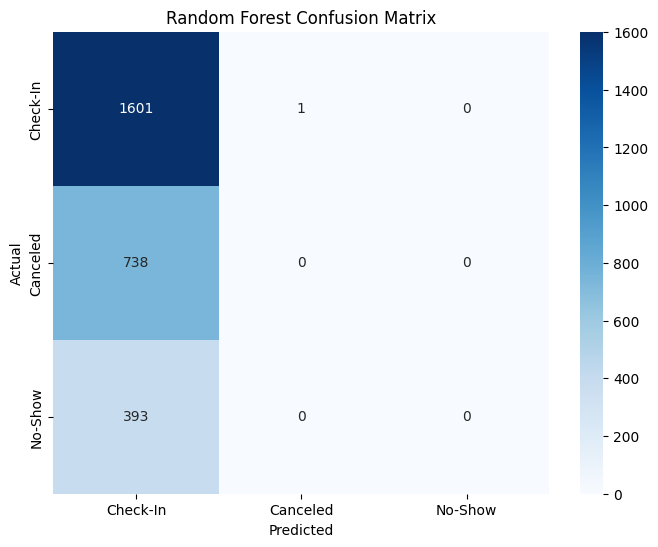

In [16]:
# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Check-In', 'Canceled', 'No-Show'],
            yticklabels=['Check-In', 'Canceled', 'No-Show'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()